In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st

In [45]:
df = pd.read_excel(r'C:\Users\Lakshya\Bank\bank-additional-full.xlsx')

In [95]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [47]:
# Select numeric columns into NumPy array
numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

data = df[numeric_cols].to_numpy()

In [48]:
# Column index helper
col = {name: i for i, name in enumerate(numeric_cols)}

**<h1 style="font-size:30px">Some Operations with Numpy</h1>**

**Mean, Median, Std of Age**

In [49]:
age = data[:, col['age']]

mean_age = np.mean(age)
median_age = np.median(age)
std_age = np.std(age)

mean_age, median_age, std_age

(np.float64(40.02406040594348),
 np.float64(38.0),
 np.float64(10.421123471838731))

**Min, Max, Range of Age**

In [50]:
min_age = np.min(age)
max_age = np.max(age)
age_range = max_age - min_age

min_age, max_age, age_range

(np.float64(17.0), np.float64(98.0), np.float64(81.0))

**Campaign Contact Analysis**

In [51]:
campaign = data[:, col['campaign']]

avg_campaign = np.mean(campaign)
max_campaign = np.max(campaign)

avg_campaign, max_campaign

(np.float64(2.567592502670681), np.float64(56.0))

**Call Duration Insights**

In [52]:
duration = data[:, col['duration']]
mean_duration = np.mean(duration)

above_mean_pct = np.sum(duration > mean_duration) / len(duration) * 100

mean_duration, above_mean_pct

(np.float64(258.2850101971448), np.float64(33.17713897251627))

**Previous Campaign Impact**

In [53]:
previous = data[:, col['previous']]

previous_contacted = previous[previous > 0]
avg_previous = np.mean(previous_contacted)

avg_previous

np.float64(1.266488888888889)

**Euribor Rate Variability**

In [54]:
euribor = data[:, col['euribor3m']]

variance_euribor = np.var(euribor)
std_euribor = np.std(euribor)

variance_euribor, std_euribor

(np.float64(3.0082347617423424), np.float64(1.7344263494718772))

**Correlation Between Age and Duration**

In [55]:
correlation = np.corrcoef(age, duration)[0, 1]

correlation

np.float64(-0.0008657050101409283)

**Employment vs Subscription Outcome**

In [56]:
# Convert y column to numeric
y_numeric = np.where(df['y'] == 'yes', 1, 0)

nr_employed = data[:, col['nr.employed']]

avg_emp_yes = np.mean(nr_employed[y_numeric == 1])
avg_emp_no = np.mean(nr_employed[y_numeric == 0])

avg_emp_yes, avg_emp_no

(np.float64(5095.115991379309), np.float64(5176.166600087557))

**Outlier Detection (Z-Score on Duration)**

In [57]:
z_scores = (duration - np.mean(duration)) / np.std(duration)

outliers = np.sum(np.abs(z_scores) > 3)

outliers

np.int64(861)

**Economic Indicators Comparison**

In [58]:
cpi = data[:, col['cons.price.idx']]
cci = data[:, col['cons.conf.idx']]

mean_cpi = np.mean(cpi)
std_cpi = np.std(cpi)

mean_cci = np.mean(cci)
std_cci = np.std(cci)

(mean_cpi, std_cpi), (mean_cci, std_cci)

((np.float64(93.57566436826262), np.float64(0.5788330221069571)),
 (np.float64(-40.50260027192386), np.float64(4.6281416720195905)))

**<h1 style="font-size:30px">Some Operations with Pandas</h1>**

**What is the subscription rate?**

In [59]:
subscription_rate = df['y'].value_counts(normalize=True) * 100
subscription_rate

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

**Which job category subscribes the most?**

In [60]:
job_subscription = df.groupby('job')['y'].value_counts(normalize=True).unstack() * 100
job_subscription.sort_values(by='yes', ascending=False)

y,no,yes
job,,
student,68.571429,31.428571
retired,74.767442,25.232558
unemployed,85.798817,14.201183
admin.,87.027442,12.972558
management,88.782490,11.217510
unknown,88.787879,11.212121
technician,89.173958,10.826042
self-employed,89.514426,10.485574
housemaid,90.000000,10.000000


**Does marital status affect subscription?**

In [61]:
marital_analysis = pd.crosstab(df['marital'], df['y'], normalize='index') * 100
marital_analysis

y,no,yes
marital,,
divorced,89.679098,10.320902
married,89.842747,10.157253
single,85.995851,14.004149
unknown,85.000000,15.000000


**Average Age of Subscribers vs Non-Subscribers**

In [62]:
age_analysis = df.groupby('y')['age'].mean()
age_analysis

y
no     39.911185
yes    40.913147
Name: age, dtype: float64

**Which month had the highest subscriptions?**

In [63]:
month_analysis = pd.crosstab(df['month'], df['y'])
month_analysis.sort_values(by='yes', ascending=False)

y,no,yes
month,,
may,12883,886
aug,5523,655
jul,6525,649
jun,4759,559
apr,2093,539
nov,3685,416
oct,403,315
mar,270,276
sep,314,256


**Education vs Subscription Rate**

In [64]:
education_analysis = pd.crosstab(df['education'], df['y'], normalize='index') * 100
education_analysis.sort_values(by='yes', ascending=False)

y,no,yes
education,,
illiterate,77.777778,22.222222
unknown,85.499711,14.500289
university.degree,86.275477,13.724523
professional.course,88.651535,11.348465
high.school,89.164477,10.835523
basic.4y,89.750958,10.249042
basic.6y,91.797557,8.202443
basic.9y,92.175352,7.824648


**Does call duration impact subscription?**

In [65]:
duration_analysis = df.groupby('y')['duration'].mean()
duration_analysis

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64

**Campaign Efficiency**

In [66]:
#(Average contacts required before subscription)

campaign_efficiency = df.groupby('y')['campaign'].mean()
campaign_efficiency

y
no     2.633085
yes    2.051724
Name: campaign, dtype: float64

**Economic Factors Impact**

In [67]:
economic_impact = df.groupby('y')[['euribor3m', 'emp.var.rate']].mean()
economic_impact

,euribor3m,emp.var.rate
y,,
no,3.811491,0.248875
yes,2.123135,-1.233448


**Correlation Matrix (Numeric Features)**

In [68]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


**Top 5 Age Groups with Highest Subscription**

In [69]:
df['age_group'] = pd.cut(df['age'], bins=[15,25,35,45,55,65,100])
age_group_analysis = pd.crosstab(df['age_group'], df['y'], normalize='index') * 100
age_group_analysis.sort_values(by='yes', ascending=False)

y,no,yes
age_group,,
"(65, 100]",53.150242,46.849758
"(15, 25]",79.051621,20.948379
"(55, 65]",84.778940,15.221060
"(25, 35]",88.280461,11.719539
"(45, 55]",91.308037,8.691963
"(35, 45]",91.490190,8.509810


**Day of Week Performance**

In [70]:
day_analysis = pd.crosstab(df['day_of_week'], df['y'], normalize='index') * 100
day_analysis.sort_values(by='yes', ascending=False)

y,no,yes
day_of_week,,
thu,87.881248,12.118752
tue,88.220025,11.779975
wed,88.332924,11.667076
fri,89.191261,10.808739
mon,90.051680,9.948320


**<h1 style="font-size:30px">Some Operations with Matplotlib</h1>**

**Plot Age Distribution (Histogram)**

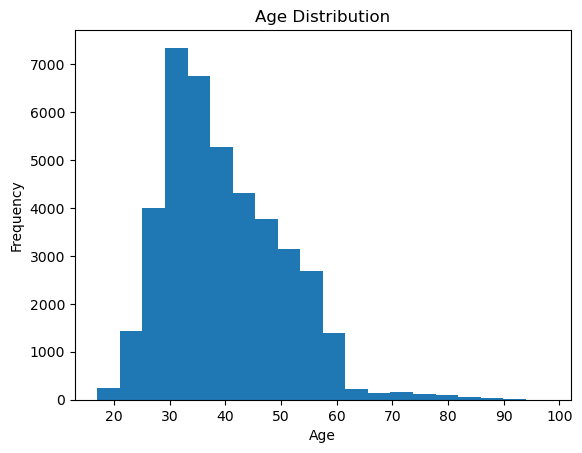

In [71]:
plt.figure()
plt.hist(df['age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

**Subscription Count (Bar Chart)**

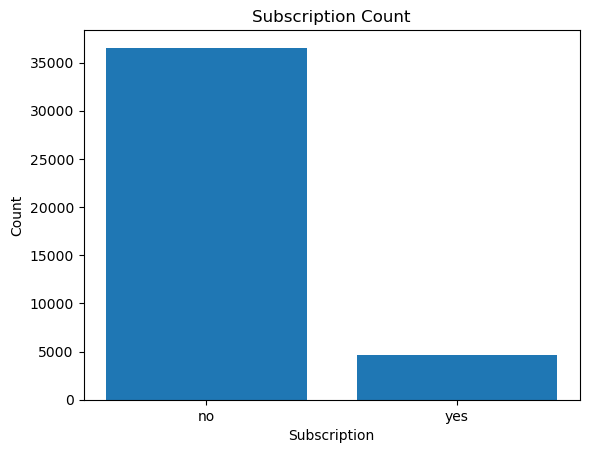

In [72]:
counts = df['y'].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.title("Subscription Count")
plt.show()

**Average Duration by Subscription**

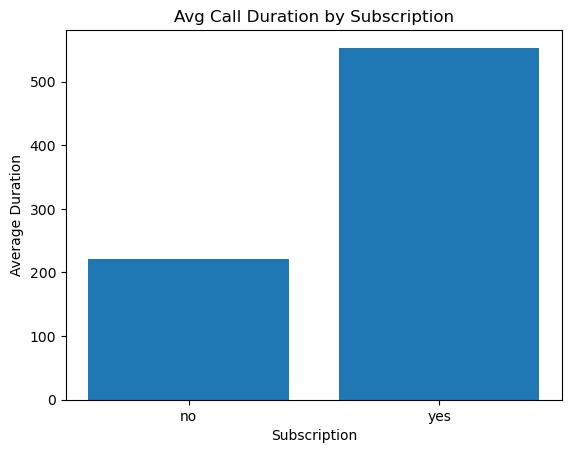

In [73]:
avg_duration = df.groupby('y')['duration'].mean()

plt.figure()
plt.bar(avg_duration.index, avg_duration.values)
plt.xlabel("Subscription")
plt.ylabel("Average Duration")
plt.title("Avg Call Duration by Subscription")
plt.show()

**Campaign Contacts Distribution**

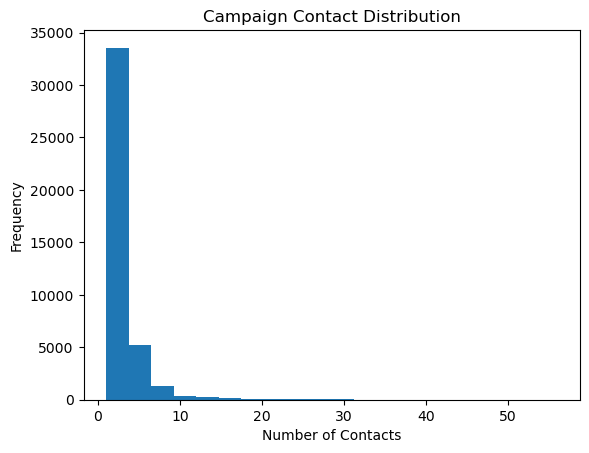

In [74]:
plt.figure()
plt.hist(df['campaign'], bins=20)
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")
plt.title("Campaign Contact Distribution")
plt.show()

**Monthly Subscription Trend**

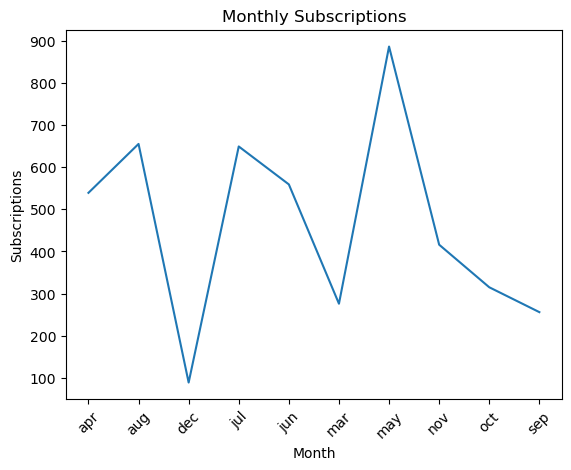

In [75]:
monthly = pd.crosstab(df['month'], df['y'])['yes']

plt.figure()
plt.plot(monthly.index, monthly.values)
plt.xlabel("Month")
plt.ylabel("Subscriptions")
plt.title("Monthly Subscriptions")
plt.xticks(rotation=45)
plt.show()

**Job Category vs Subscriptions**

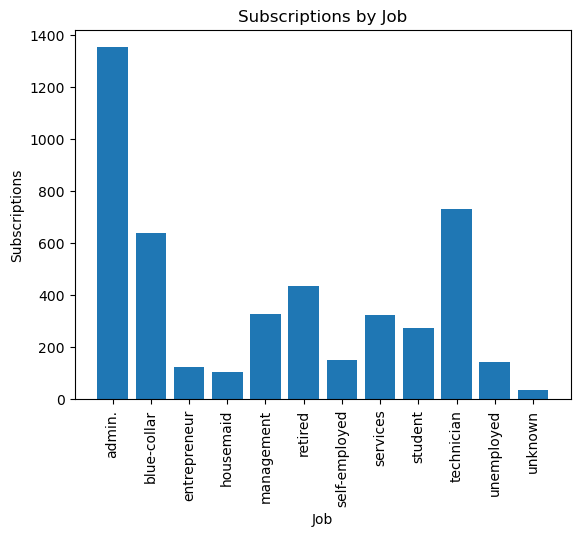

In [76]:
job_sub = pd.crosstab(df['job'], df['y'])['yes']

plt.figure()
plt.bar(job_sub.index, job_sub.values)
plt.xlabel("Job")
plt.ylabel("Subscriptions")
plt.title("Subscriptions by Job")
plt.xticks(rotation=90)
plt.show()

**Correlation Heatmap (Using Matplotlib Only)**

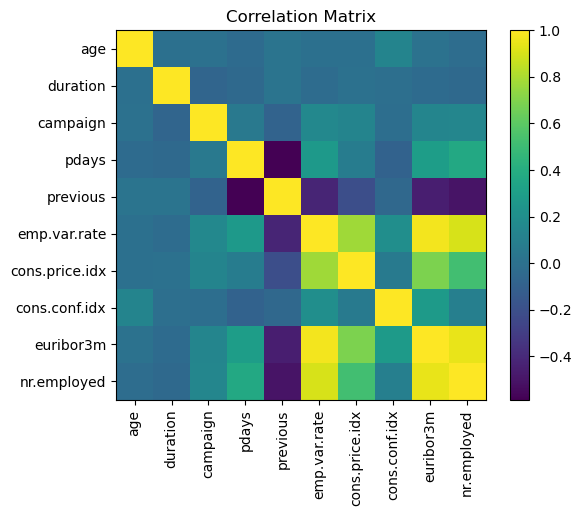

In [77]:
corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

**Age vs Duration (Scatter Plot)**

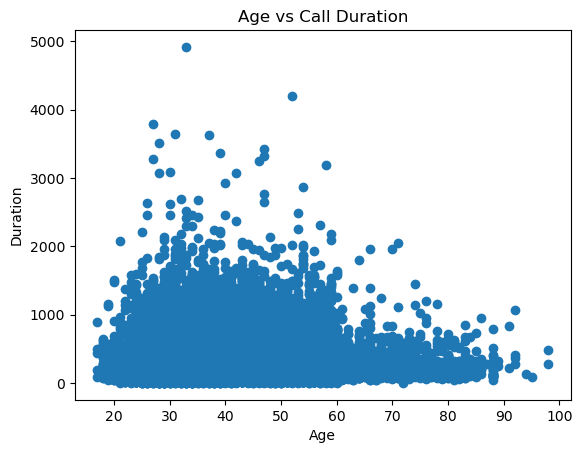

In [78]:
plt.figure()
plt.scatter(df['age'], df['duration'])
plt.xlabel("Age")
plt.ylabel("Duration")
plt.title("Age vs Call Duration")
plt.show()

**Economic Indicator Trend (Line Plot)**

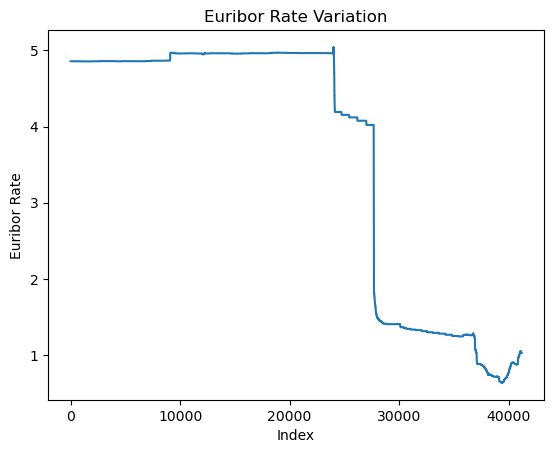

In [79]:
plt.figure()
plt.plot(df['euribor3m'])
plt.xlabel("Index")
plt.ylabel("Euribor Rate")
plt.title("Euribor Rate Variation")
plt.show()

**Subscription by Age Group (Bar Chart)**

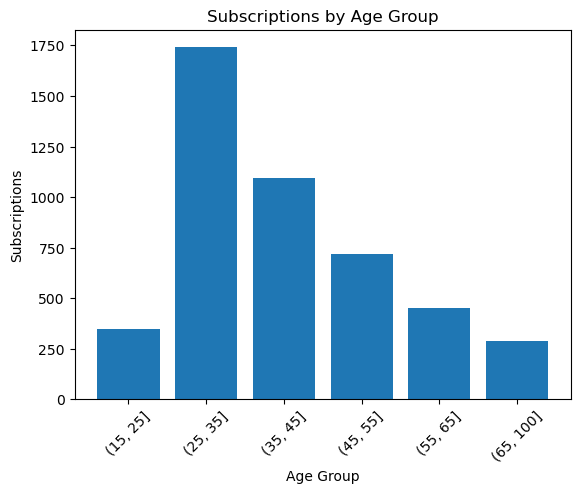

In [80]:
df['age_group'] = pd.cut(df['age'], bins=[15,25,35,45,55,65,100])

age_group = pd.crosstab(df['age_group'], df['y'])['yes']

plt.figure()
plt.bar(age_group.index.astype(str), age_group.values)
plt.xlabel("Age Group")
plt.ylabel("Subscriptions")
plt.title("Subscriptions by Age Group")
plt.xticks(rotation=45)
plt.show()

**<h1 style="font-size:30px">Dashboard Script</h1>**

In [93]:
# =====================================================
# DATA LOADING
# =====================================================

@st.cache_data
def load_data(path):
    df = pd.read_excel(path)
    return df

df = load_data(r"C:\Users\Lakshya\Bank\bank-additional-full.xlsx")

# =====================================================
# ---------------- Sidebar Filters --------------------
# =====================================================

st.sidebar.header("🔎 Filters")

jobs = ["All"] + sorted(df['job'].dropna().unique().tolist())
selected_job = st.sidebar.selectbox("Job", jobs)

education = ["All"] + sorted(df['education'].dropna().unique().tolist())
selected_edu = st.sidebar.selectbox("Education", education)

age_range = st.sidebar.slider("Age Range",
                              int(df['age'].min()),
                              int(df['age'].max()),
                              (25, 60))

# Apply filters
filtered_df = df.copy()
if selected_job != "All":
    filtered_df = filtered_df[filtered_df['job'] == selected_job]

if selected_edu != "All":
    filtered_df = filtered_df[filtered_df['education'] == selected_edu]

filtered_df = filtered_df[
    filtered_df['age'].between(age_range[0], age_range[1])
]

# =====================================================
# HEADER & KPI BLOCK
# =====================================================

st.title("Bank Marketing Campaign — Executive Analytics Dashboard")

total_records = len(filtered_df)
subscription_rate = (filtered_df["y"] == "yes").mean() * 100
avg_age = filtered_df["age"].mean()
avg_duration = filtered_df["duration"].mean()
avg_contacts = filtered_df["campaign"].mean()

c1, c2, c3, c4, c5 = st.columns(5)

c1.metric("Total Records", f"{total_records:,}")
c2.metric("Subscription Rate (%)", f"{subscription_rate:.2f}")
c3.metric("Avg Age", f"{avg_age:.1f}")
c4.metric("Avg Call Duration", f"{avg_duration:.1f}")
c5.metric("Avg Campaign Contacts", f"{avg_contacts:.2f}")

# =====================================================
# DATA EXPORT
# =====================================================

csv_buffer = io.StringIO()
filtered_df.to_csv(csv_buffer, index=False)

st.download_button(
    "Download Filtered Dataset",
    csv_buffer.getvalue(),
    "bank_filtered.csv",
    "text/csv"
)

# =====================================================
# TABS
# =====================================================

tab1, tab2, tab3 = st.tabs([
    "Statistical Engine (NumPy)",
    "Business Intelligence (Pandas)",
    "Visual Analytics (Matplotlib)"
])

# =====================================================
# TAB 1 — NUMPY ENGINE
# =====================================================

with tab1:

    st.subheader("Core Statistical Metrics")

    numeric_cols = [
        'age', 'duration', 'campaign', 'pdays', 'previous',
        'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
        'euribor3m', 'nr.employed'
    ]

    data = filtered_df[numeric_cols].to_numpy()
    col = {name: i for i, name in enumerate(numeric_cols)}

    age = data[:, col["age"]]
    duration = data[:, col["duration"]]
    euribor = data[:, col["euribor3m"]]

    stats_df = pd.DataFrame({
        "Metric": ["Mean Age", "Median Age", "Std Age",
                   "Mean Duration", "Duration Outliers (Z>3)",
                   "Age-Duration Correlation",
                   "Euribor Variance"],
        "Value": [
            np.mean(age),
            np.median(age),
            np.std(age),
            np.mean(duration),
            np.sum(np.abs((duration - np.mean(duration)) / np.std(duration)) > 3),
            np.corrcoef(age, duration)[0, 1],
            np.var(euribor)
        ]
    })

    st.dataframe(stats_df, use_container_width=True)

# =====================================================
# TAB 2 — PANDAS BUSINESS INTELLIGENCE
# =====================================================

with tab2:

    st.subheader("Subscription Performance Analysis")

    subscription_table = (
        filtered_df["y"]
        .value_counts(normalize=True) * 100
    )
    st.dataframe(subscription_table)

    st.subheader("Subscription Rate by Job")
    job_analysis = (
        pd.crosstab(filtered_df["job"], filtered_df["y"], normalize="index") * 100
    ).sort_values(by="yes", ascending=False)
    st.dataframe(job_analysis)

    st.subheader("Education Impact")
    edu_analysis = (
        pd.crosstab(filtered_df["education"], filtered_df["y"], normalize="index") * 100
    ).sort_values(by="yes", ascending=False)
    st.dataframe(edu_analysis)

    st.subheader("Economic Indicators vs Subscription")
    econ_analysis = (
        filtered_df.groupby("y")[["euribor3m", "emp.var.rate"]].mean()
    )
    st.dataframe(econ_analysis)

    st.subheader("Correlation Matrix")
    st.dataframe(filtered_df.corr(numeric_only=True))

# =====================================================
# TAB 3 — FULL MATPLOTLIB ANALYTICS
# =====================================================

with tab3:

    st.subheader("Age Distribution")
    fig, ax = plt.subplots()
    ax.hist(filtered_df["age"], bins=25)
    ax.set_xlabel("Age")
    ax.set_ylabel("Frequency")
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Subscription Count")
    fig, ax = plt.subplots()
    counts = filtered_df["y"].value_counts()
    ax.bar(counts.index, counts.values)
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Average Duration by Subscription")
    fig, ax = plt.subplots()
    avg_duration = filtered_df.groupby("y")["duration"].mean()
    ax.bar(avg_duration.index, avg_duration.values)
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Campaign Contacts Distribution")
    fig, ax = plt.subplots()
    ax.hist(filtered_df["campaign"], bins=30)
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Monthly Subscription Trend")
    monthly = pd.crosstab(filtered_df["month"], filtered_df["y"])["yes"]
    fig, ax = plt.subplots()
    ax.plot(monthly.index, monthly.values)
    ax.set_xticklabels(monthly.index, rotation=45)
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Subscriptions by Job")
    job_sub = pd.crosstab(filtered_df["job"], filtered_df["y"])["yes"]
    fig, ax = plt.subplots()
    ax.bar(job_sub.index, job_sub.values)
    ax.set_xticklabels(job_sub.index, rotation=90)
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Correlation Heatmap (Matplotlib Native)")
    corr = filtered_df.corr(numeric_only=True)
    fig, ax = plt.subplots()
    cax = ax.imshow(corr)
    plt.colorbar(cax)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Age vs Call Duration")
    fig, ax = plt.subplots()
    ax.scatter(filtered_df["age"], filtered_df["duration"], alpha=0.4)
    ax.set_xlabel("Age")
    ax.set_ylabel("Duration")
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Euribor Rate Trend")
    fig, ax = plt.subplots()
    ax.plot(filtered_df["euribor3m"].values)
    ax.set_ylabel("Euribor 3M")
    st.pyplot(fig)
    plt.close(fig)

    st.subheader("Subscription by Age Group")
    filtered_df["age_group"] = pd.cut(
        filtered_df["age"],
        bins=[15, 25, 35, 45, 55, 65, 100]
    )

    age_group = pd.crosstab(filtered_df["age_group"], filtered_df["y"])["yes"]

    fig, ax = plt.subplots()
    ax.bar(age_group.index.astype(str), age_group.values)
    ax.set_xticklabels(age_group.index.astype(str), rotation=45)
    st.pyplot(fig)
    plt.close(fig)

2026-02-05 18:24:55.230 No runtime found, using MemoryCacheStorageManager
2026-02-05 18:24:55.291 No runtime found, using MemoryCacheStorageManager
2026-02-05 18:24:55.345 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-05 18:24:55.362 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-05 18:24:55.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-05 18:24:56.010 Thread 'Thread-18': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-05 18:24:56.104 Thread 'Thread-18': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-05 18:25:23.769 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-05 18:25:23.771 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored

In [85]:
# !jupyter nbconvert --to script "Bank-Data-Analysis.ipynb"

[NbConvertApp] Converting notebook Bank-Data-Analysis.ipynb to script
[NbConvertApp] Writing 12333 bytes to Bank-Data-Analysis.py
